# Reflectance Exercise 5 — comparing reflectance response models

Normalise retained measurements, compare linear, quadratic and power-law response shapes for one sensor, then inspect all five channels.

Start with the supplied synthetic example so that every cell runs before you have collected data. The example demonstrates the analysis route; it is not evidence about your robot and its values are not coursework answers. You do not need to understand or edit the example-generation cell.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(2026)


## 1. Use the example or your own data

Leave `USE_EXAMPLE_DATA` set to `True` for your first run. To use your measurements, upload the CSV, change it to `False`, and enter its filename. This is the main data-loading setting you need to edit.

Expected raw CSV columns: `test_name`, `surface_value`, `trial_num`, `sample_num`, `sample_time`, `sensor_num`, and `sensor_reading`.

This notebook reuses the Exercise 4 structure and adds derived normalised values and predictions.


In [2]:
USE_EXAMPLE_DATA = True
CSV_FILENAME = "reflectance_exercise05.csv"

print("Using:", "synthetic example" if USE_EXAMPLE_DATA else CSV_FILENAME)


Using: synthetic example


## 2. Create the small synthetic example

The example contains five differently scaled channels with similar but not identical response shapes.


In [3]:
rows = []
surface_values = [220, 190, 160, 130, 100, 70, 40]
baselines = [225, 250, 235, 265, 240]
saturations = [1740, 1810, 1775, 1850, 1790]
gammas = [0.85, 1.15, 1.10, 1.20, 1.05]
for trial_num in range(1, 4):
    for condition_num, surface_value in enumerate(surface_values):
        u = (220 - surface_value) / (220 - 40)
        for sample_num in range(1, 16):
            sample_time = trial_num * 1_000_000 + (condition_num * 15 + sample_num) * 10_000
            for sensor_num in range(5):
                expected = baselines[sensor_num] + (saturations[sensor_num] - baselines[sensor_num]) * u ** gammas[sensor_num]
                rows.append({
                    "test_name": "responseShapeTest", "surface_value": surface_value,
                    "trial_num": trial_num, "sample_num": sample_num,
                    "sample_time": sample_time, "sensor_num": sensor_num,
                    "sensor_reading": expected + rng.normal(0, 12),
                })
example_data = pd.DataFrame(rows)


## 3. Load and preview the selected data

This is where an uploaded CSV enters the notebook. Check that the column names, units and labels match the exercise before continuing.


In [4]:
if USE_EXAMPLE_DATA:
    data = example_data.copy()
else:
    data = pd.read_csv(CSV_FILENAME)

data.head()


,test_name,surface_value,trial_num,sample_num,sample_time,sensor_num,sensor_reading
0,responseShapeTest,220,1,1,1010000,0,215.482530
1,responseShapeTest,220,1,1,1010000,1,252.886855
2,responseShapeTest,220,1,1,1010000,2,212.244084
3,responseShapeTest,220,1,1,1010000,3,281.749261
4,responseShapeTest,220,1,1,1010000,4,247.659537


## 4. Enter your measured reference values

Replace this table with the five white-reference and operational saturation values supported by Exercises 2 and 3. These are independent measurements and must not be estimated from held-back rows.


In [5]:
sensor_references = pd.DataFrame({
    "sensor_num": [0, 1, 2, 3, 4],
    "white_reference_us": [225, 250, 235, 265, 240],
    "saturation_reference_us": [1740, 1810, 1775, 1850, 1790],
})
TEST_NAME = "responseShapeTest"
SELECTED_SENSOR = 0
LIGHT_SURFACE_VALUE = 220.0
DARK_SURFACE_VALUE = 40.0
HELD_BACK_SURFACE_VALUES = [160, 100]
sensor_references


,sensor_num,white_reference_us,saturation_reference_us
0,0,225,1740
1,1,250,1810
2,2,235,1775
3,3,265,1850
4,4,240,1790


## 5. Plot the selected sensor's raw observations first


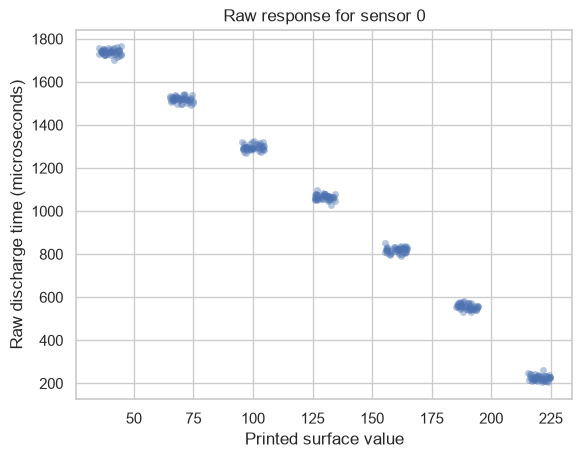

In [6]:
selected_raw = data.loc[
    (data["test_name"] == TEST_NAME) & (data["sensor_num"] == SELECTED_SENSOR)
].copy()
sns.stripplot(data=selected_raw, x="surface_value", y="sensor_reading", jitter=0.16, alpha=0.4, native_scale=True)
plt.title(f"Raw response for sensor {SELECTED_SENSOR}")
plt.xlabel("Printed surface value")
plt.ylabel("Raw discharge time (microseconds)")
plt.show()


## 6. Add normalised columns without changing raw readings

`merge` attaches the matching measured references to each sensor row. The new columns `u` and `v` follow the exercise equations.


In [7]:
analysis = data.loc[data["test_name"] == TEST_NAME].merge(
    sensor_references, on="sensor_num", validate="many_to_one"
)
analysis["u"] = ((LIGHT_SURFACE_VALUE - analysis["surface_value"])
                 / (LIGHT_SURFACE_VALUE - DARK_SURFACE_VALUE))
analysis["v"] = ((analysis["sensor_reading"] - analysis["white_reference_us"])
                 / (analysis["saturation_reference_us"] - analysis["white_reference_us"]))
analysis["split"] = np.where(
    analysis["surface_value"].isin(HELD_BACK_SURFACE_VALUES), "held back", "fit"
)
selected = analysis.loc[analysis["sensor_num"] == SELECTED_SENSOR].copy()
selected[["surface_value", "sensor_reading", "u", "v", "split"]].head()


,surface_value,sensor_reading,u,v,split
0,220,215.482530,0.0,-0.006282,fit
5,220,221.495430,0.0,-0.002313,fit
10,220,233.640814,0.0,0.005704,fit
15,220,217.631779,0.0,-0.004864,fit
20,220,219.272655,0.0,-0.003780,fit


## 7. Fit the three candidate equations

- linear reference: $\hat{v}=u$;
- quadratic: $\hat{v}=A+Bu+Cu^2$;
- power law: $\hat{v}=u^\gamma$.

The quadratic and power law use only rows labelled `fit`. The short
gamma search chooses the exponent with the smallest fitting error.


In [8]:
def choose_gamma(u, v):
    candidates = np.linspace(0.2, 3.0, 561)
    errors = [np.mean((v - u ** gamma) ** 2) for gamma in candidates]
    return candidates[np.argmin(errors)]

condition_summary = (
    selected.groupby(["surface_value", "u", "split"], as_index=False)
    .agg(v=("v", "mean"), repeat_sd=("v", "std"))
)
fitting_rows = condition_summary.loc[
    (condition_summary["split"] == "fit") & condition_summary["u"].between(0, 1)
]
C, B, A = np.polyfit(fitting_rows["u"], fitting_rows["v"], 2)
gamma = choose_gamma(fitting_rows["u"], fitting_rows["v"])
condition_summary["linear"] = condition_summary["u"]
condition_summary["quadratic"] = A + B * condition_summary["u"] + C * condition_summary["u"] ** 2
condition_summary["power law"] = condition_summary["u"] ** gamma
coefficients = pd.DataFrame([
    {"model": "linear reference", "symbol": "fixed", "value": 1.0},
    {"model": "quadratic", "symbol": "A", "value": A},
    {"model": "quadratic", "symbol": "B", "value": B},
    {"model": "quadratic", "symbol": "C", "value": C},
    {"model": "power law", "symbol": "gamma", "value": gamma},
])
print("Linear reference: v_hat = u")
print(f"Quadratic: v_hat = {A:.3f} {B:+.3f}u {C:+.3f}u^2")
print(f"Power law: v_hat = u^{gamma:.3f}")
coefficients


Linear reference: v_hat = u
Quadratic: v_hat = 0.009 +1.213u -0.228u^2
Power law: v_hat = u^0.850


,model,symbol,value
0,linear reference,fixed,1.000000
1,quadratic,A,0.008896
2,quadratic,B,1.213123
3,quadratic,C,-0.227621
4,power law,gamma,0.850000


## 8. Plot the candidates against the same observations

`melt` places the prediction columns into one labelled column so Seaborn can draw one line per model.


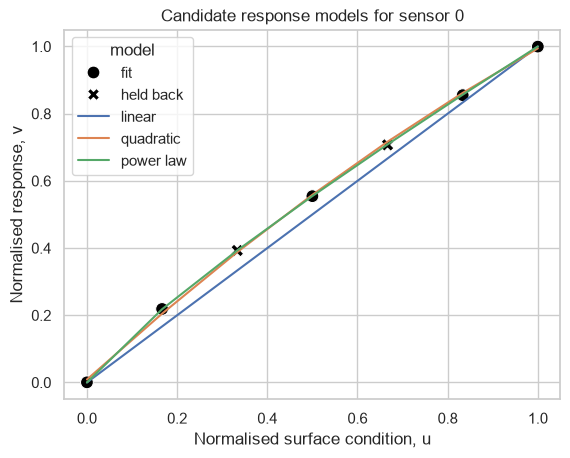

In [9]:
prediction_plot = condition_summary.melt(
    id_vars=["surface_value", "u", "v", "repeat_sd", "split"],
    value_vars=["linear", "quadratic", "power law"],
    var_name="model", value_name="predicted_v",
)
sns.scatterplot(data=condition_summary, x="u", y="v", style="split", color="black", s=85)
sns.lineplot(data=prediction_plot, x="u", y="predicted_v", hue="model")
plt.title(f"Candidate response models for sensor {SELECTED_SENSOR}")
plt.xlabel("Normalised surface condition, u")
plt.ylabel("Normalised response, v")
plt.show()


## 9. Compare residual patterns and held-back error


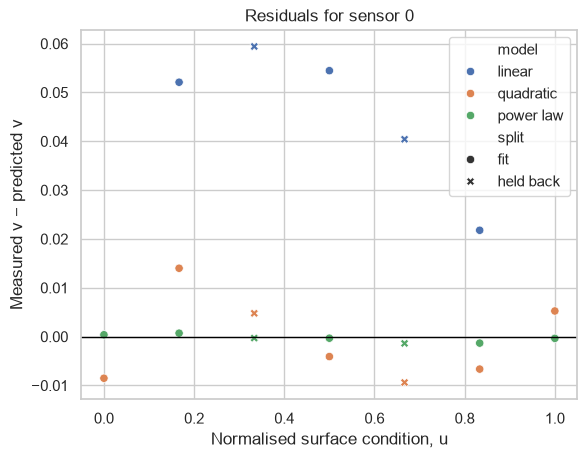

,model,split,MAE
0,linear,fit,0.025815
1,linear,held back,0.049922
2,power law,fit,0.000616
3,power law,held back,0.000839
4,quadratic,fit,0.007702
5,quadratic,held back,0.007081


In [10]:
prediction_plot["residual"] = prediction_plot["v"] - prediction_plot["predicted_v"]
prediction_plot["absolute_error"] = prediction_plot["residual"].abs()
sns.scatterplot(data=prediction_plot, x="u", y="residual", hue="model", style="split")
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Residuals for sensor {SELECTED_SENSOR}")
plt.xlabel("Normalised surface condition, u")
plt.ylabel("Measured v − predicted v")
plt.show()
error_summary = (
    prediction_plot.groupby(["model", "split"], as_index=False)
    .agg(MAE=("absolute_error", "mean"))
)
error_summary


## 10. Compare all five normalised responses

Once the selected-sensor route is clear, this plot repeats normalisation for all channels. The next table compares separate gamma values with one shared gamma using held-back conditions.


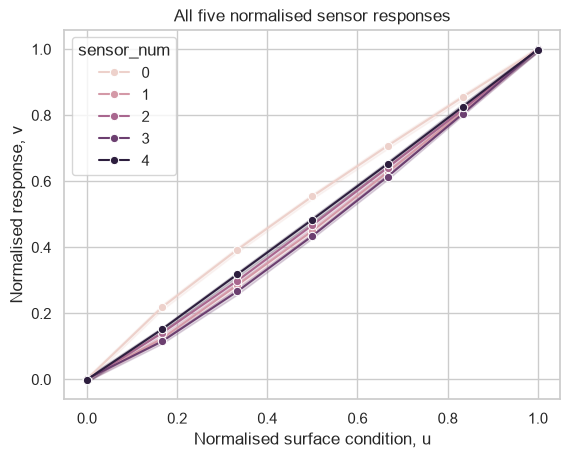

In [11]:
sns.lineplot(data=analysis, x="u", y="v", hue="sensor_num", marker="o", estimator="mean", errorbar="sd")
plt.title("All five normalised sensor responses")
plt.xlabel("Normalised surface condition, u")
plt.ylabel("Normalised response, v")
plt.show()


In [12]:
all_summary = (
    analysis.groupby(["sensor_num", "surface_value", "u", "split"], as_index=False)
    .agg(v=("v", "mean"))
)
all_fitting = all_summary.loc[
    (all_summary["split"] == "fit") & all_summary["u"].between(0, 1)
]
shared_gamma = choose_gamma(all_fitting["u"], all_fitting["v"])
gamma_rows = []
for sensor_num, sensor_rows in all_summary.groupby("sensor_num"):
    sensor_fit = sensor_rows.loc[(sensor_rows["split"] == "fit") & sensor_rows["u"].between(0, 1)]
    sensor_held = sensor_rows.loc[sensor_rows["split"] == "held back"]
    separate_gamma = choose_gamma(sensor_fit["u"], sensor_fit["v"])
    gamma_rows.append({
        "sensor_num": sensor_num, "separate_gamma": separate_gamma,
        "separate_gamma_held_back_MAE": np.mean(np.abs(sensor_held["v"] - sensor_held["u"] ** separate_gamma)),
        "shared_gamma_held_back_MAE": np.mean(np.abs(sensor_held["v"] - sensor_held["u"] ** shared_gamma)),
    })
gamma_comparison = pd.DataFrame(gamma_rows)
print(f"Shared gamma: {shared_gamma:.3f}")
gamma_comparison


Shared gamma: 1.065


,sensor_num,separate_gamma,separate_gamma_held_back_MAE,shared_gamma_held_back_MAE
0,0,0.850,0.000839,0.070079
1,1,1.155,0.002679,0.023565
2,2,1.095,0.001091,0.010048
3,3,1.200,0.001003,0.039686
4,4,1.050,0.001480,0.005384


## What to notice

- Do held-back errors support a more complex model?
- Do residuals show a repeatable curve rather than random scatter?
- Change `SELECTED_SENSOR` and rerun the detailed comparison for every channel.
- Does one shared gamma predict nearly as well as separate values?
- Printer fill and normalised response are not calibrated physical reflectance.
